In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
with open ('household_power_consumption.txt', 'r') as f:
    df = pd.read_csv(f, sep=';', low_memory=False, na_values=['?'])

# Columns Description 
`Global_active_power`

global_active_power * 1000 / 60 -> it converts from kW to Wh 

`Global_reactive_power` : 
Reactive power in the home


`Voltage` : 
The electrical voltage supplied to the house.

`Global_intensity` : 
The total electrical current drawn by the house. Ampere

`Sub_metering_1` : 
Kitchen machines consumption -> Dishwasher, Oven and  Microwave

`Sub_metering_2` : 
laundry room -> Dryer , Waching Machine, Refrigerator and Lights

`Sub_metering_3` : 
water heater + air conditioner

# Data Analysis

In [59]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


It seems that the values of features 0 to 5 have some issues

In [61]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [62]:
df.shape

(2075259, 9)

In [63]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [64]:
df['Sub_metering_1'].value_counts()

Sub_metering_1
0.0     1880175
1.0       84936
2.0       19017
38.0      16119
37.0      14892
         ...   
82.0          3
88.0          3
87.0          3
84.0          2
86.0          2
Name: count, Length: 88, dtype: int64

In [65]:
df.dropna(inplace=True) # drop missing values
df.insert(0,'Datetime',pd.to_datetime(df['Date']+' '+df['Time'],dayfirst=True)) # merging Date and Time columns
df.drop(columns=['Date','Time'],inplace=True) # Dropping The Date and Time columns
df.set_index('Datetime',inplace=True) # Set Datetime values as index
df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0


In [66]:
df.index.duplicated().sum()

np.int64(0)

The value numbers are saved in string format. therefore, they must be changed into float64.

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2049280 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 189.6 MB


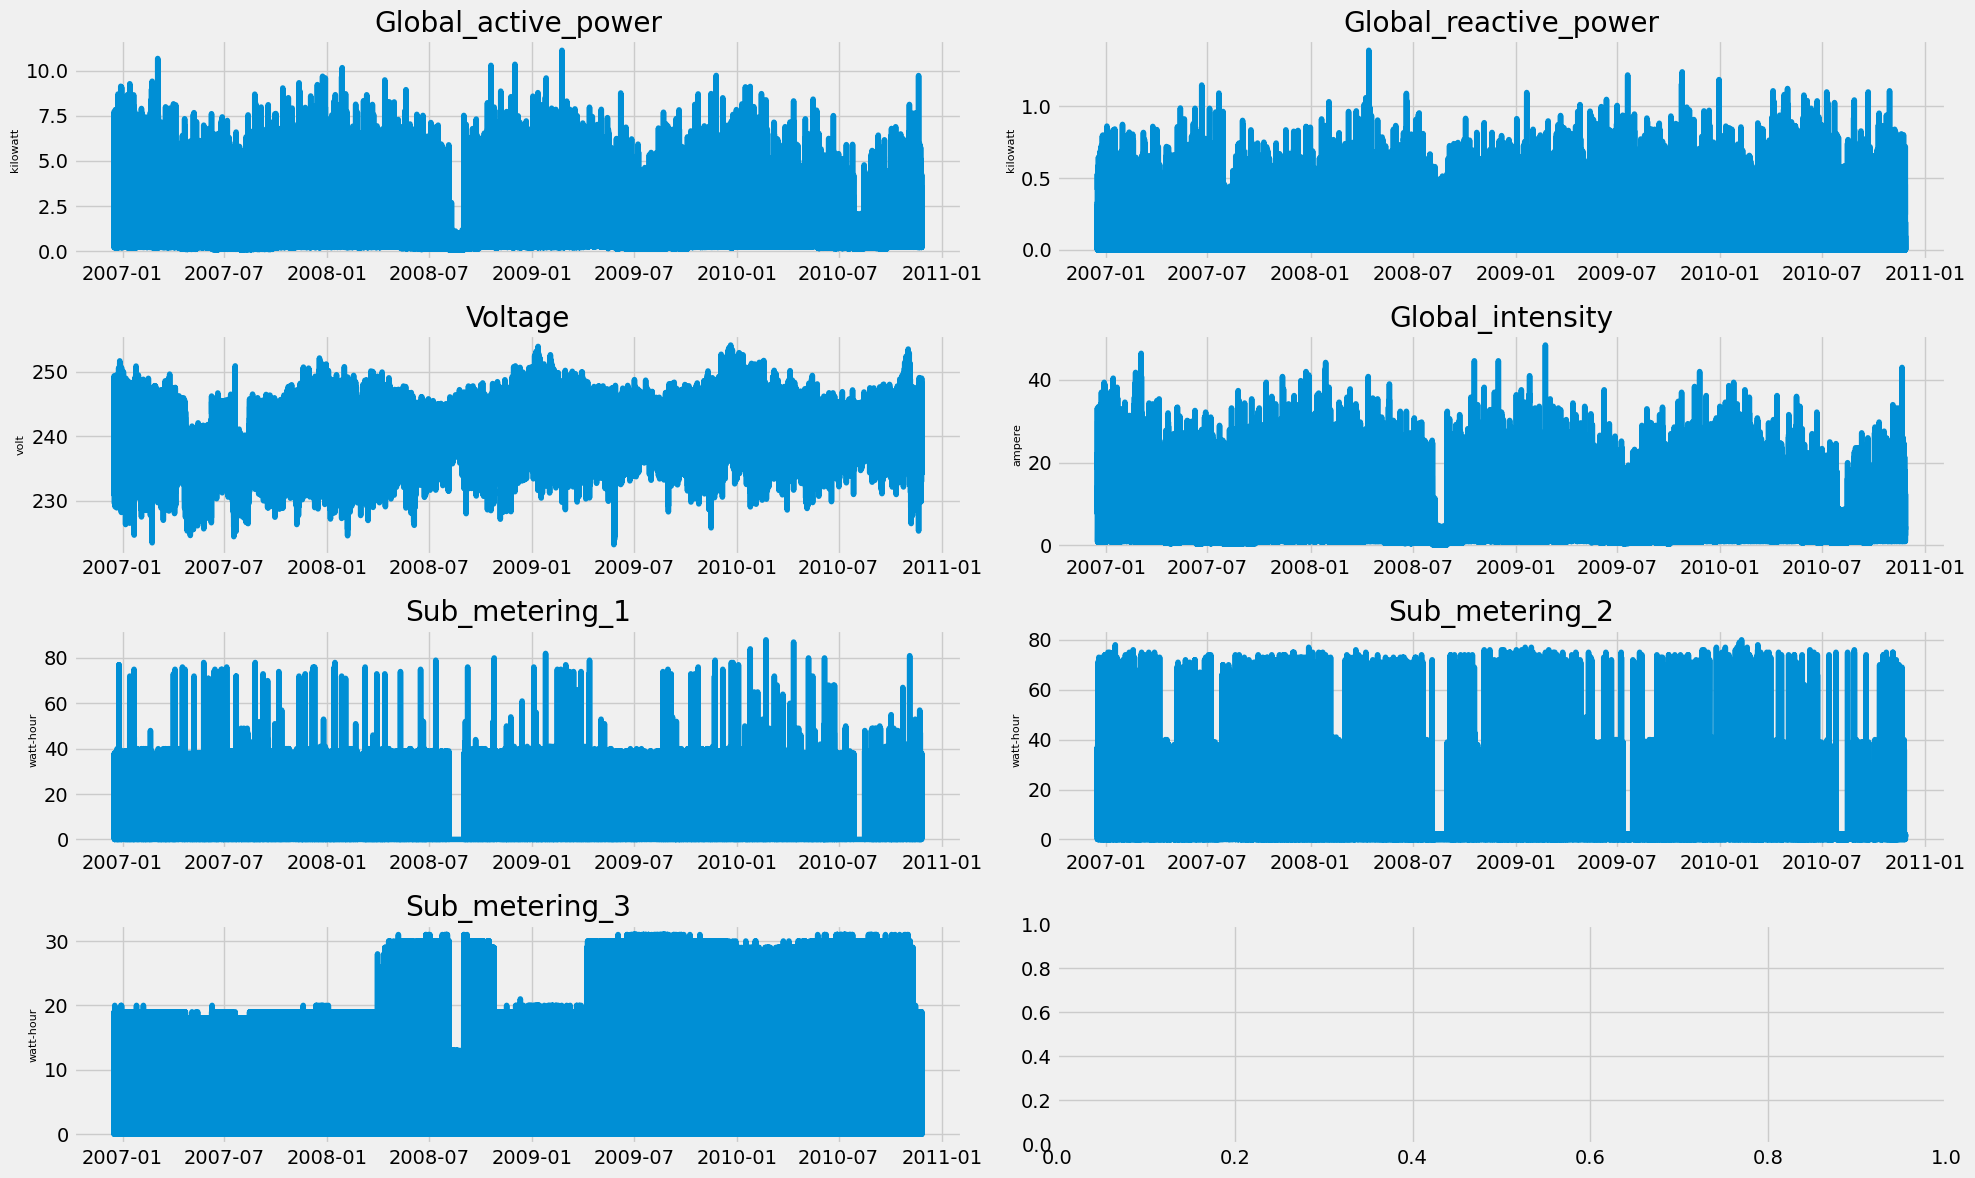

In [ ]:
meters = {'power': 'kilowatt',
          'Voltage': 'volt',
          'intensity': 'ampere',
          'metering': 'watt-hour'}

fig, axs = plt.subplots(4, 2, figsize=(20, 12))
for i, col in enumerate(df.columns):
    row       = i // 2  # Calculate the row index
    col_index = i % 2   # Calculate the column index
    axs[row, col_index].plot(df.index, df[col])  # Access the subplot using two indices
    if 'power' in col:  
        if 'factor' in col:
            axs[row, col_index].set_title('Power Factor')
            axs[row, col_index].set_ylabel('Degrees', fontsize=8)
        else:
            axs[row, col_index].set_title(col)  # Set title for each subplot
            axs[row, col_index].set_ylabel(meters['power'], fontsize=8)
    elif 'Voltage' in col:
        axs[row, col_index].set_ylabel(meters['Voltage'], fontsize=8)
        axs[row, col_index].set_title(col)  # Set title for each subplot
    elif 'intensity' in col:
        axs[row, col_index].set_ylabel(meters['intensity'], fontsize=8)
        axs[row, col_index].set_title(col)  # Set title for each subplot
    elif 'metering' in col:
        axs[row, col_index].set_ylabel(meters['metering'], fontsize=8)
        if '1' in col:
            axs[row, col_index].set_title(col)
        elif '2' in col:
            axs[row, col_index].set_title(col)
        elif '3' in col:
            axs[row, col_index].set_title(col)

plt.tight_layout()
plt.show()

p = i*v

* There is a huge reduction in all parameters during a short period between 2008-07 and 2008-10.
* In addition to the above-mentioned period, there are some smaller periods with similar behaviors throughout all the datetimes.
* There are two periods with a sharp decrease in voltage between 2008-04 and 2008-09.
* There are several spikes in Submetering_1 and Submetering_2.
* There is an approximately steady behavior in Submetering_3, except for the ending periods with a significant fluctuation in power consumption.

<Axes: >

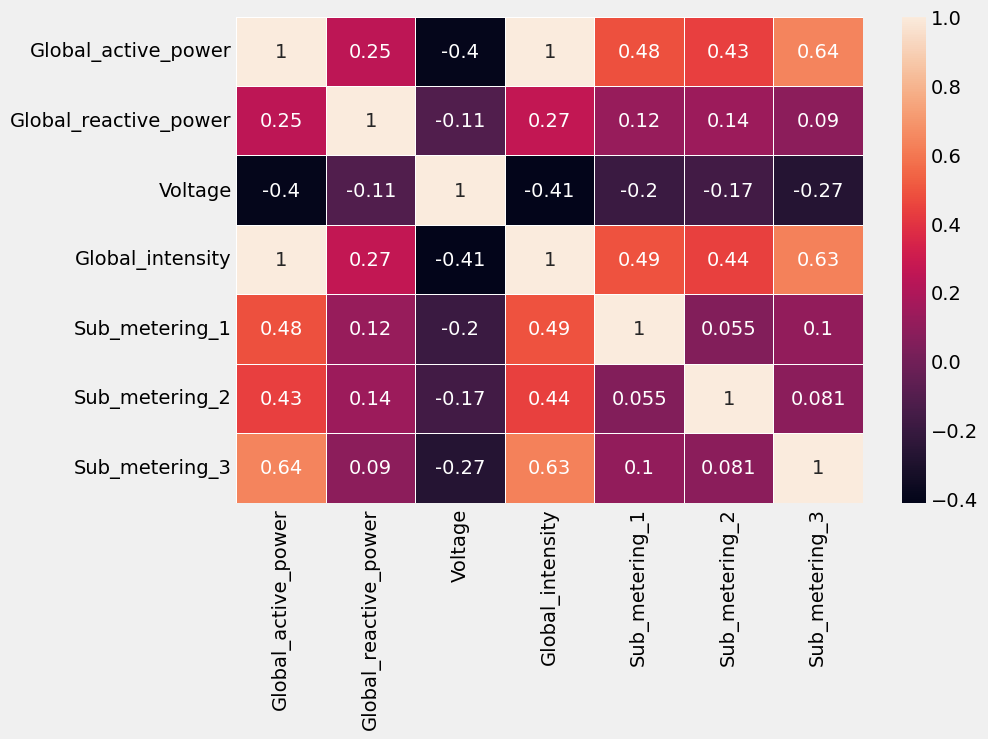

In [69]:
# Compute the correlation matrix
corr = df.corr()

f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, linewidths=.5, ax=ax)

It is clear that the Global intensity and Sub_metering_3 have positive realtions with the Global active power.  
The Voltage parameter has negative relation with the all parameters in this dataset. One reason could be that the other parameters show consumption behavior. Spikes in the load profile would reduce the power quality.

# XGBOOST Model

In [70]:
import xgboost as xgb
from sklearn import preprocessing
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [71]:
X_scaled  = preprocessing.StandardScaler().fit_transform(df.reset_index(drop=True))
df_scaled = pd.DataFrame(data=X_scaled, columns=df.columns)
df_scaled['Datetime'] = df.index
df_scaled.set_index('Datetime',inplace=True)

df_scaled['hour'] = df_scaled.index.hour
df_scaled['day of week'] = df_scaled.index.dayofweek
df_scaled['quarter'] = df_scaled.index.quarter
df_scaled['month'] = df_scaled.index.month
df_scaled['year'] = df_scaled.index.year
df_scaled['day of year'] = df_scaled.index.dayofyear

df_scaled

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day of week,quarter,month,year,day of year
Datetime,,,,,,,,,,,,,
2006-12-16 17:24:00,2.955077,2.610721,-1.851816,3.098789,-0.182337,-0.051274,1.249421,17,5,4,12,2006,350
2006-12-16 17:25:00,4.037085,2.770406,-2.225274,4.133800,-0.182337,-0.051274,1.130897,17,5,4,12,2006,350
2006-12-16 17:26:00,4.050326,3.320432,-2.330213,4.133800,-0.182337,0.120487,1.249421,17,5,4,12,2006,350
2006-12-16 17:27:00,4.063567,3.355917,-2.191324,4.133800,-0.182337,-0.051274,1.249421,17,5,4,12,2006,350
2006-12-16 17:28:00,2.434881,3.586573,-1.592556,2.513782,-0.182337,-0.051274,1.249421,17,5,4,12,2006,350
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,-0.137724,-1.097519,-0.126500,-0.141247,-0.182337,-0.223036,-0.765477,20,4,4,11,2010,330
2010-11-26 20:59:00,-0.139616,-1.097519,-0.259217,-0.141247,-0.182337,-0.223036,-0.765477,20,4,4,11,2010,330
2010-11-26 21:00:00,-0.145291,-1.097519,-0.314772,-0.186248,-0.182337,-0.223036,-0.765477,21,4,4,11,2010,330



### In power sytems analysis there is an important term called power factor<br>
### Look at the picture below <br>
<br><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/Cmplxpower.svg" alt="Power Factor"> <br> 
### Q is Reactive Power which flows back and forth between source and load  
### R is Active power that directly consumed on the demand side  
### S is Apparent power that is the product of the RMS values of voltage and current.  
Apparent power S =sqrt(R^2 + Q^2)


### Power factor is equal to R/S


​

In [72]:
active_power_sq = np.square(df['Global_active_power'])
reactive_power_sq = np.square(df['Global_reactive_power'])

apparent_power = np.sqrt(active_power_sq + reactive_power_sq)

# Compute numerator once
power_factor = df['Global_active_power'] / apparent_power


df_scaled['power_factor'] = power_factor

df_scaled

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day of week,quarter,month,year,day of year,power_factor
Datetime,,,,,,,,,,,,,,
2006-12-16 17:24:00,2.955077,2.610721,-1.851816,3.098789,-0.182337,-0.051274,1.249421,17,5,4,12,2006,350,0.995121
2006-12-16 17:25:00,4.037085,2.770406,-2.225274,4.133800,-0.182337,-0.051274,1.130897,17,5,4,12,2006,350,0.996708
2006-12-16 17:26:00,4.050326,3.320432,-2.330213,4.133800,-0.182337,0.120487,1.249421,17,5,4,12,2006,350,0.995734
2006-12-16 17:27:00,4.063567,3.355917,-2.191324,4.133800,-0.182337,-0.051274,1.249421,17,5,4,12,2006,350,0.995688
2006-12-16 17:28:00,2.434881,3.586573,-1.592556,2.513782,-0.182337,-0.051274,1.249421,17,5,4,12,2006,350,0.989787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,-0.137724,-1.097519,-0.126500,-0.141247,-0.182337,-0.223036,-0.765477,20,4,4,11,2010,330,1.000000
2010-11-26 20:59:00,-0.139616,-1.097519,-0.259217,-0.141247,-0.182337,-0.223036,-0.765477,20,4,4,11,2010,330,1.000000
2010-11-26 21:00:00,-0.145291,-1.097519,-0.314772,-0.186248,-0.182337,-0.223036,-0.765477,21,4,4,11,2010,330,1.000000


In [73]:
df_scaled['power_factor'].describe()

count    2.049280e+06
mean     9.636864e-01
std      5.810473e-02
min      5.558553e-01
25%      9.519593e-01
50%      9.934251e-01
75%      9.997272e-01
max      1.000000e+00
Name: power_factor, dtype: float64

In [74]:
df_scaled['power_factor'].isna().sum()

np.int64(0)

In [75]:
df_scaled['power_factor'].min(), df_scaled['power_factor'].max()

(np.float64(0.5558552855084361), np.float64(1.0))

In [76]:
cols = ['Global_active_power','Global_reactive_power']#,'Voltage']#,'Sub_metering_1','Sub_metering_2','Sub_metering_3']

train    = df_scaled[df_scaled.index<'2008-12-12'].drop(columns=cols)
test     = df_scaled[df_scaled.index>='2008-12-12'].drop(columns=cols)
target   = 'power_factor'
features = train.columns.drop([target])
X_train  = train[features]
y_train  = train[target]
X_test   = test[features]
y_test   = test[target]


model = xgb.XGBRegressor(n_estimators=1024,early_stopping_rounds=10,
                       learning_rate=0.002)
model.fit(X_train,y_train,
        eval_set=[(X_train,y_train),(X_test,y_test)],
        verbose=True)
print(model.best_score,model.best_iteration)


prediction = model.predict(X_test)
test.loc[test.index,'prediction']= prediction

[0]	validation_0-rmse:0.06262	validation_1-rmse:0.05293
[1]	validation_0-rmse:0.06254	validation_1-rmse:0.05286
[2]	validation_0-rmse:0.06247	validation_1-rmse:0.05278
[3]	validation_0-rmse:0.06239	validation_1-rmse:0.05271
[4]	validation_0-rmse:0.06232	validation_1-rmse:0.05264
[5]	validation_0-rmse:0.06224	validation_1-rmse:0.05256
[6]	validation_0-rmse:0.06217	validation_1-rmse:0.05249
[7]	validation_0-rmse:0.06209	validation_1-rmse:0.05241
[8]	validation_0-rmse:0.06202	validation_1-rmse:0.05234
[9]	validation_0-rmse:0.06194	validation_1-rmse:0.05227
[10]	validation_0-rmse:0.06187	validation_1-rmse:0.05219
[11]	validation_0-rmse:0.06179	validation_1-rmse:0.05212
[12]	validation_0-rmse:0.06172	validation_1-rmse:0.05205
[13]	validation_0-rmse:0.06165	validation_1-rmse:0.05198
[14]	validation_0-rmse:0.06157	validation_1-rmse:0.05190
[15]	validation_0-rmse:0.06150	validation_1-rmse:0.05183
[16]	validation_0-rmse:0.06142	validation_1-rmse:0.05176
[17]	validation_0-rmse:0.06135	validation

d:\SIC-AI\Support\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


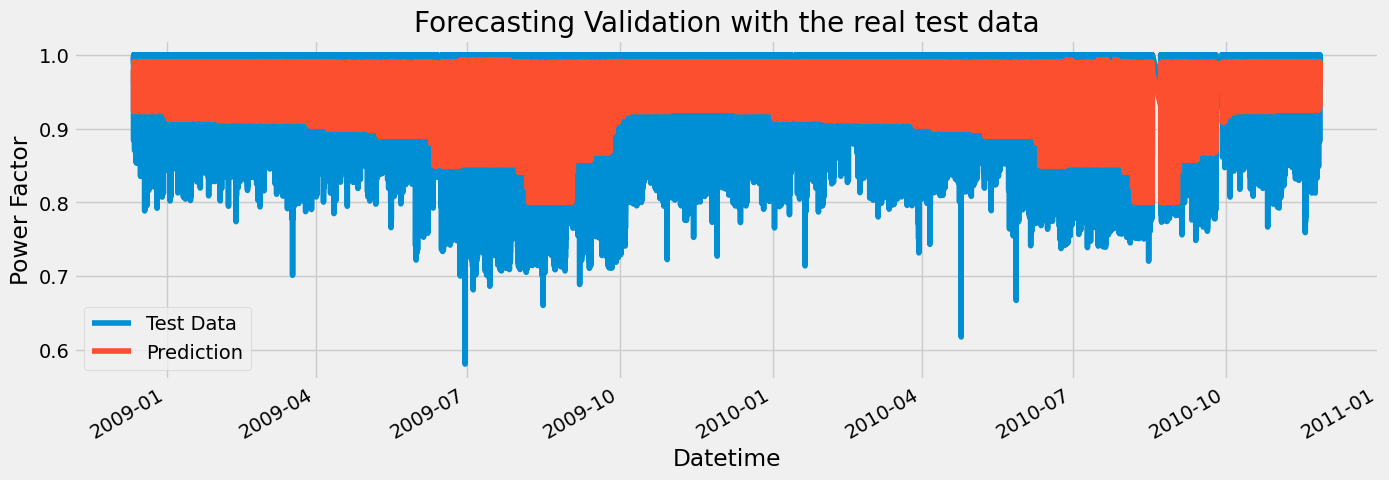

In [77]:
ax = test.loc[test.index>'2008-12-12','power_factor'].plot(figsize=(15,5))
test.loc[test.index>'2008-12-12','prediction'].plot(ax=ax)
plt.legend(['Test Data','Prediction'])
ax.set_title('Forecasting Validation with the real test data')
ax.set_ylabel('Power Factor')
plt.show()